In [1]:
import pandas as pd
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

import matplotlib

matplotlib.rcParams['date.converter'] = 'concise'
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.size'] = 14

In [2]:
""" Compare unique spike clusters detected by coVar vs SAMRefiner """
SPIKE_REGION = (21563, 25384)

def filter_spike(cluster):
    output = []
    for mut in cluster:
        if int(mut[1:-1]) in range(SPIKE_REGION[0], SPIKE_REGION[1] + 1):
            output.append(mut)
    return output

# Parse results

# samrefiner
samrefiner_df = pd.read_csv('../results/samrefiner/jn.1.1_10000_merged.trimmed_unique_seqs.tsv', sep='\t', header=1)
samrefiner_df['clusters'] = samrefiner_df['Unique Sequence'].str.split(' ').str[1:-1].apply(lambda x: [m.split('(')[0] for m in x if ('-' not in m and m != 'Reference') and m.split('(')[0][-1] != 'N']).apply(filter_spike)
samrefiner_df['clusters'] = samrefiner_df['clusters'].apply(lambda x: ' '.join(x))
samrefiner_clusters = set(samrefiner_df['clusters'])
samrefiner_clusters.remove('')

# covar
covar_df = pd.read_csv('../results/covar/covar_10000.tsv', sep='\t')
covar_df['clusters'] = covar_df['nt_mutations'].str.split(' ').apply(lambda x: [m for m in x if ('-' not in m and '+' not in m)]).apply(filter_spike)
covar_df['clusters'] = covar_df['clusters'].apply(lambda x: ' '.join(x))
covar_clusters = set(covar_df['clusters'])
covar_clusters.remove('')

# crykey
crykey_df = pd.read_csv('../results/crykey/cryptic_dataframe/1012023_test.csv')
crykey_df['clusters'] = crykey_df['Nt Mutations'].str.split(';').apply(lambda x: [m for m in x if ('-' not in m and '+' not in m)]).apply(filter_spike)
crykey_df['clusters'] = crykey_df['clusters'].apply(lambda x: ' '.join(x))
crykey_clusters = set(crykey_df['clusters'])
crykey_clusters.remove('')


print(f'SAMRefiner clusters: {len(samrefiner_clusters)}')
print(f'coVar clusters: {len(covar_clusters)}')
print(f'Crykey clusters: {len(crykey_clusters)}')

SAMRefiner clusters: 3189
coVar clusters: 3189
Crykey clusters: 2195


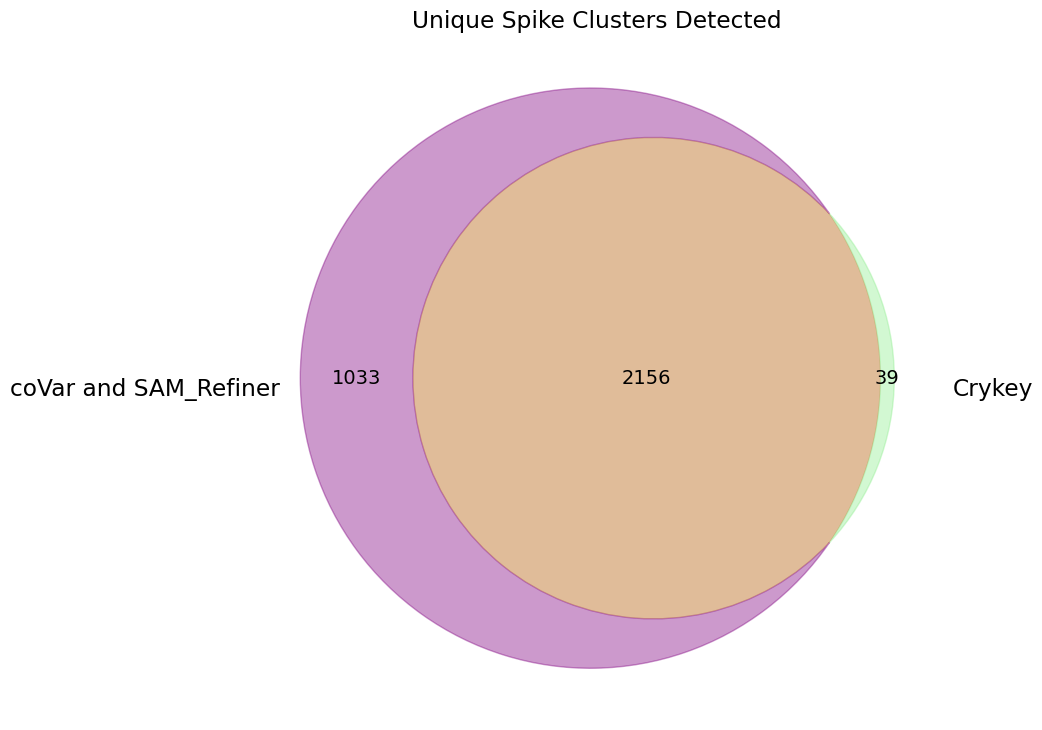

In [3]:
# Create a Venn diagram

#save clusters in samrefiner that are not in covar
unique_samrefiner_clusters = samrefiner_clusters - covar_clusters - crykey_clusters
# save to tsv
unique_samrefiner_df = pd.DataFrame(unique_samrefiner_clusters, columns=['clusters'])
unique_samrefiner_df.to_csv('samrefiner_unique_clusters.tsv', sep='\t', index=False)

# save clusters in covar that are not in crykey
unique_covar_clusters = covar_clusters - crykey_clusters
# save to tsv
unique_covar_df = pd.DataFrame(unique_covar_clusters, columns=['clusters'])
unique_covar_df.to_csv('covar_unique_clusters.tsv', sep='\t', index=False)

# save clusters in crykey that are not in samrefiner
unique_crykey_clusters = crykey_clusters - samrefiner_clusters - covar_clusters
# save to tsv
unique_crykey_df = pd.DataFrame(unique_crykey_clusters, columns=['clusters'])
unique_crykey_df.to_csv('crykey_unique_clusters.tsv', sep='\t', index
=False)
plt.figure(figsize=(9, 11))

# covar and samrefiner overlap completely, so we group them together here
v = venn2(subsets=[covar_clusters, crykey_clusters], set_labels=('A', 'B'))
v.get_patch_by_id('10').set_color('purple')  # coVar and SAM_Refiner
v.get_patch_by_id('01').set_color('lightgreen')  # Crykey

# move labels
v.get_label_by_id('A').set_x(-0.65)
v.get_label_by_id('A').set_y(0)
v.get_label_by_id('B').set_x(0.65)
v.get_label_by_id('B').set_y(0)

v.get_label_by_id('A').set_text('coVar and SAM_Refiner')
v.get_label_by_id('B').set_text('Crykey')


plt.title('Unique Spike Clusters Detected')
plt.savefig('../results/accuracy_venn_unfiltered.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [4]:
# Compare unique clusters detected by covar/samrefiner vs crykey

unique_crykey_df = pd.DataFrame(unique_crykey_clusters, columns=['clusters'])

# Get the number fraction of crykey clusters that are subets of covar/samrefiner clusters
for index, row in unique_crykey_df.iterrows():
    crykey_cluster = row['clusters']
    for covar_cluster in covar_df['clusters']:
        if all(m in covar_cluster for m in crykey_cluster.split(' ')):
            print(f'Crykey cluster {crykey_cluster} is a subset of covar cluster {covar_cluster}')
            unique_crykey_df.at[index, 'is_subset_of_covar'] = True
            break

unique_crykey_df = unique_crykey_df.fillna(False)

#print false cluster
print(f'Percent of crykey clusters that are subsets of covar/samrefiner clusters: {unique_crykey_df[unique_crykey_df["is_subset_of_covar"]].shape[0] / unique_crykey_df.shape[0] * 100:.2f}%')


Crykey cluster A22359C G22381C A22400T is a subset of covar cluster C22353A A22359C G22381C A22400T
Crykey cluster G22992A C22995A T23005A T23008A G23012A T23019C A23055G A23063T is a subset of covar cluster G22992A C22995A T23005A T23008A G23012A T23018C T23019C A23055G A23063T T23075C
Crykey cluster G22992A C22995A T23005A T23008A G23012A T23018C T23019C A23055G A23063T G23066T is a subset of covar cluster G22992A C22995A T23005A T23008A G23012A T23018C T23019C A23055G A23063T G23066T T23075A
Crykey cluster A21927C G21941T is a subset of covar cluster A21927C G21941T C21977A
Crykey cluster T25039A T25058G G25062C is a subset of covar cluster C25000T T25039A T25058G G25062C
Crykey cluster G22992A C22995A T23005A T23008A G23012A T23018C T23019C A23041T A23055G A23063T is a subset of covar cluster G22992A C22995A T23005A T23008A G23012A T23018C T23019C A23041T A23055G A23063T T23075C
Crykey cluster G22992A C22995A T23005A T23008A G23012A T23018C T23019C A23055G A23063T A23064T is a subs

/tmp/ipykernel_3594960/4195959384.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  unique_crykey_df = unique_crykey_df.fillna(False)
